# Phân cụm dữ liệu bằng giải thuật K-means (unsupervised learning)

## Mục tiêu 
- Hiểu hoạt động của giải thuật K-means 
- Biết cách sử dụng K-means: thay đổi tham số, đánh giá chất lượng
- Ứng dụng 

## Dữ liệu 
- Sử dụng hàm sinh dữ liệu tự động của sklearn (sinh ra các điểm ngẫu nhiên theo phân phối Gauss)
- Mỗi dữ liệu là một điểm trên mặt phẳng Oxy
- Ảnh bird_small.png: hình ảnh về một chú chim, được sử dụng để minh họa tác dụng của K-means trong việc nén ảnh

## Yêu cầu
- Sử dụng K-means để phân loại các điểm dữ liệu. 
- Thử nghiệm các trường hợp có số cụm nhiều hơn hoặc ít hơn 

# Các thư viện sử dụng 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs


# Chuẩn bị dữ liệu 
- Sinh dữ liệu ngẫu nhiên n_samples = 100 tương đương 100 điểm 
    - random_state: biến cố định hàm random - để các điểm sinh ngẫu nhiên 
    
- Mỗi điểm dữ liệu có 2 chiều 

In [2]:
n_samples = 100
random_state = 170
center_points = [[1, 1], [-1, -1], [1, -1]] # sinh ngẫu nhiên các điểm xung quanh vị trí tâm cố định 
# center_points = 3                           # tâm cụm được chọn ngẫu nhiên

X, y = make_blobs(n_samples=n_samples, random_state=random_state, centers=center_points, cluster_std=0.6)
print("Số chiều dữ liệu: ", X.shape, y.shape)
print("5 điểm dữ liệu đầu tiên: \n", X[:5])

Số chiều dữ liệu:  (100, 2) (100,)
5 điểm dữ liệu đầu tiên: 
 [[ 1.26241305  0.94872541]
 [-0.39743873 -1.18567406]
 [ 1.35081331  0.48041993]
 [ 1.21219555  0.98929291]
 [-0.75344338 -1.09784774]]


**Vẽ các điểm ảnh sử dụng matlib plot**

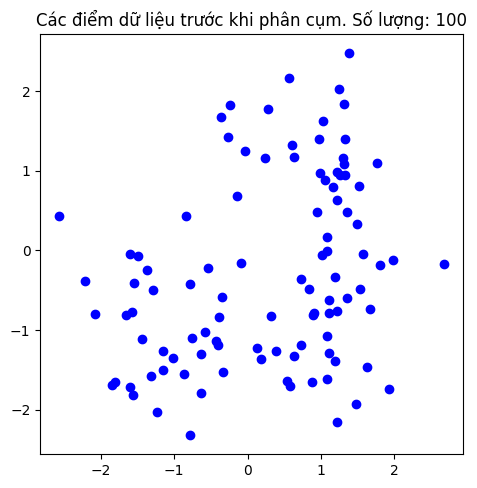

In [3]:
plt.figure(figsize=(12, 12))
plt.subplot(221)
plt.scatter(X[:, 0], X[:, 1], c='blue') # c là tham số chọn màu sắc, có thể truyền vào string hoặc số id 1,2,3 ...
plt.title("Các điểm dữ liệu trước khi phân cụm. Số lượng: {}".format(n_samples))
plt.show()

#  Dựng giải thuật K-means và huấn luyện
- Sử dụng thư viện sklearn để xây dựng giải thuật K-means, xem chi tiết tại [tài liệu hướng dẫn](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)

In [4]:
k_cluster = 3
k_mean_model = KMeans(n_clusters=k_cluster, random_state=random_state)
k_mean_model.fit(X)

centers = np.array(k_mean_model.cluster_centers_) # cluster_centers_: là thuộc tính lưu trữ các 
                                                  # tâm cụm sau khi training 
print("Tâm cụm sau khi training ({} tâm): \n".format(k_cluster),
      centers)


Tâm cụm sau khi training (3 tâm): 
 [[ 1.11177838 -0.94555162]
 [ 0.88823619  1.19442485]
 [-1.13949326 -0.97100768]]


c:\Users\admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


# Kiểm tra giải thuật K-means 

- Kiểm tra các điểm dữ liệu thuộc vào cụm nào 
- Vẽ biểu đồ hiển thị, trong đó các điểm thuộc các cụm khác nhau sẽ có các màu khác nhau 

Kết quả dự đoán cho 5 mẫu dữ liệu đầu tiên trong tập data: 

[1 2 1 1 2]


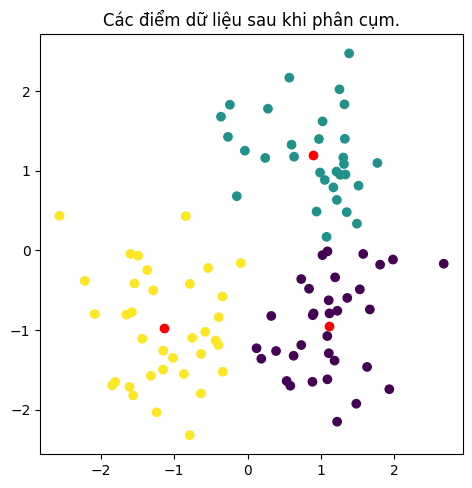

In [5]:
y_pred = k_mean_model.predict(X)
print("Kết quả dự đoán cho 5 mẫu dữ liệu đầu tiên trong tập data: \n")
print(y_pred[:5])

plt.figure(figsize=(12, 12))
plt.subplot(222)
plt.scatter(X[:, 0], X[:, 1], c=y_pred)
plt.scatter(centers[:, 0], centers[:, 1], c='red')
plt.title("Các điểm dữ liệu sau khi phân cụm.")
plt.show()

# Bài tập 1
Yêu cầu: Thử nghiệm trường hợp dữ liệu sinh ra chỉ có 2 cụm nhưng huấn luyện K-means với các tham số k = 3,4,5 cụm

- Tự viết code sinh dữ liệu tương tự bên trên
- Xây dựng mô hình 3,4,5 cụm

Gợi ý: thay đổi tham số số cụm khi dựng giải thuật K-means

Kết quả phải ra được hình ảnh thể hiện đúng số tâm cụm và phân bố cụm. 

# Ứng dụng nén ảnh 

- Đặt vấn đề:
    - Muốn xây dựng 1 hệ thống nén dữ liệu hình ảnh 
    - Có thể tuỳ chỉnh được độ sắc nét, giảm kích thước bộ nhớ, nhưng không làm sai lệch quá nhiều dưới mắt nhìn.  
- Giải pháp
    - Sử dụng giải thuật K-means, tự động phân cụm các điểm ảnh, giới hạn số lượng màu để giảm kích thước ảnh 
    - Mỗi điểm ảnh sẽ được quy về 1 cụm nào đó, mang giá trị màu bằng màu của tâm cụm. 


## Thư viện sử dụng - hỗ trợ hình ảnh 

In [6]:
from skimage import io
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as image
from IPython.core.display import Image, display

C:\Users\admin\AppData\Local\Temp\ipykernel_21472\2555458203.py:6: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import Image, display


## Đọc dữ liệu hình ảnh
- Mỗi điểm ảnh là 1 mẫu quan sát 
- Phân cụm tập dữ liệu (tập các điểm ảnh) về k nhãn

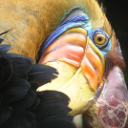

Dữ liệu ảnh trước khi reshape: (128, 128, 3)
Số chiều của dữ liệu hình ảnh:  (16384, 3)
Tổng số điểm ảnh là:  16384
Mỗi điểm ảnh có số chiều =  3


In [7]:
path_img = 'bird_small.png'

display(Image(path_img, width=250, unconfined=True))

img = io.imread(path_img)
print("Dữ liệu ảnh trước khi reshape:", img.shape)

img_shape = img.shape # 128x128x3
data_img = (img / 255.0).reshape(-1,img.shape[2]) # chuyển ma trận 128x128x3 về mảng 2 chiều, giữ lại chiều .shape[2]                    

print("Số chiều của dữ liệu hình ảnh: ", data_img.shape)
print("Tổng số điểm ảnh là: ", data_img.shape[0])
print("Mỗi điểm ảnh có số chiều = ", data_img.shape[1])

## Xây dựng mô hình kmean để nén ảnh 
- Số lượng cụm chính là số lượng màu ta giữ lại 
- Số lượng cụm càng nhỏ thì kích thước ảnh cho ra càng nhỏ 

In [12]:
n_color = 20
k_mean_model = KMeans(n_clusters=n_color)

**Huấn luyện mô hình**  

In [13]:
k_mean_model.fit(data_img)

,n_clusters,20
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [14]:
# Hiển thị một số thông tin đã học của mô hình 
print("Số chiều của tâm cụm: ", k_mean_model.cluster_centers_.shape)
print(k_mean_model.cluster_centers_)
print(k_mean_model.labels_[0:20])

Số chiều của tâm cụm:  (20, 3)
[[0.97808791 0.90113473 0.714082  ]
 [0.14373885 0.14970039 0.14124975]
 [0.50553555 0.40804589 0.35083367]
 [0.83481264 0.71622918 0.47610367]
 [0.2423125  0.22544856 0.2188267 ]
 [0.97215743 0.96067648 0.85640022]
 [0.69756493 0.51248192 0.2411649 ]
 [0.59235467 0.51111935 0.459684  ]
 [0.41686329 0.30003526 0.20699699]
 [0.5711591  0.72486142 0.87169686]
 [0.40237572 0.4755024  0.67255716]
 [0.57576929 0.41859883 0.17536854]
 [0.08067187 0.08741448 0.07705889]
 [0.32223771 0.33786823 0.38172103]
 [0.69346683 0.62508691 0.57352246]
 [0.95083591 0.82033319 0.56600914]
 [0.7608949  0.61535026 0.35523372]
 [0.91983703 0.67785842 0.3833397 ]
 [0.82813036 0.74587159 0.74043655]
 [0.90813946 0.54529979 0.21118467]]
[17  3  3 17 17  3  3  3 17 17 17  3 17 17 17 17 17 17 17 17]


## Sinh dữ liệu ảnh mới 

In [15]:
# k_mean_model.labels_: chứa nhãn của tất cả các điểm ảnh 
# k_mean_model.cluster_centers_: chứa các tâm cụm. 
#new_arr = arr1[index]
img128=k_mean_model.cluster_centers_[k_mean_model.labels_]

print(img128.shape)

# chuẩn hoá lại kích thước ảnh theo chiều dài, rộng ban đầu 
img128=np.reshape(img128, img_shape)
print(img128.shape)
image.imsave('img128.png', img128)

(16384, 3)
(128, 128, 3)


In [28]:
import os
from IPython.core.display import Image, display

C:\Users\admin\AppData\Local\Temp\ipykernel_21472\479266747.py:2: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import Image, display


In [29]:
# hiển thị kích thước hình ảnh trước và sau khi nén 
print('Size of compressed image: ' + str(os.path.getsize('img128.png')) + ' KB')
print('Size of original image: ' + str(os.path.getsize('bird_small.png')) + ' KB')

Size of compressed image: 11392 KB
Size of original image: 33031 KB


# Bài tập 2
Yêu cầu: Nén ảnh trên thành ảnh có số màu < 5 và kiểm tra 

Gợi ý: thay đổi tham số "số cụm" khi xây dựng K-means 

In [18]:
m_color = 4
k_mean_model = KMeans(n_clusters=m_color)
k_mean_model.fit(data_img)

,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [19]:
print("Số chiều của tâm cụm: ", k_mean_model.cluster_centers_.shape)
print(k_mean_model.cluster_centers_)
print(k_mean_model.labels_[0:20])

Số chiều của tâm cụm:  (4, 3)
[[0.79100396 0.63697114 0.41816735]
 [0.12750585 0.12946152 0.11993415]
 [0.91158681 0.85865891 0.73968696]
 [0.48385426 0.39712652 0.32109727]]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [20]:
# k_mean_model.labels_: chứa nhãn của tất cả các điểm ảnh 
# k_mean_model.cluster_centers_: chứa các tâm cụm. 
#new_arr = arr1[index]
img12=k_mean_model.cluster_centers_[k_mean_model.labels_]

print(img12.shape)

# chuẩn hoá lại kích thước ảnh theo chiều dài, rộng ban đầu 
img12=np.reshape(img12, img_shape)
print(img12.shape)
image.imsave('img12.png', img12)

(16384, 3)
(128, 128, 3)


In [21]:
# hiển thị kích thước hình ảnh trước và sau khi nén 
import os
print('Size of compressed image: ' + str(os.path.getsize('img12.png')) + ' KB')
print('Size of original image: ' + str(os.path.getsize('bird_small.png')) + ' KB')

Size of compressed image: 3433 KB
Size of original image: 33031 KB


### Nén ảnh thành số màu 200

In [30]:
color = 200
k_mean_model = KMeans(n_clusters=color)
k_mean_model.fit(data_img)

,n_clusters,200
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [31]:
# k_mean_model.labels_: chứa nhãn của tất cả các điểm ảnh 
# k_mean_model.cluster_centers_: chứa các tâm cụm. 
#new_arr = arr1[index]
img1080=k_mean_model.cluster_centers_[k_mean_model.labels_]

print(img1080.shape)

# chuẩn hoá lại kích thước ảnh theo chiều dài, rộng ban đầu 
img1080=np.reshape(img1080, img_shape)
print(img1080.shape)
image.imsave('img1080.png', img1080)

(16384, 3)
(128, 128, 3)


In [32]:
# hiển thị kích thước hình ảnh trước và sau khi nén 
print('Size of compressed image: ' + str(os.path.getsize('img1080.png')) + ' KB')
print('Size of original image: ' + str(os.path.getsize('bird_small.png')) + ' KB')

Size of compressed image: 28179 KB
Size of original image: 33031 KB


Hiển thị ảnh sau khi nén:
Kích thước ảnh sau khi nén:
Ảnh với số màu 4:


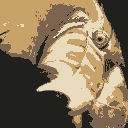

Ảnh với số màu 20:


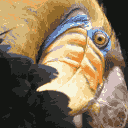

Ảnh với số màu 200:


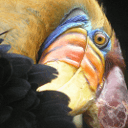

Ảnh gốc:


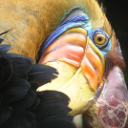

In [35]:
#Save image
print("Hiển thị ảnh sau khi nén:")
print("Kích thước ảnh sau khi nén:")
print("Ảnh với số màu 4:")
display(Image('img12.png', width=250, unconfined=True))
print("Ảnh với số màu 20:")
display(Image('img128.png', width=250, unconfined=True))
print("Ảnh với số màu 200:")
display(Image('img1080.png', width=250, unconfined=True))
print("Ảnh gốc:")
display(Image(path_img, width=250, unconfined=True))